# On the failure of MO coefficients: Fock matrix edition

**NOTE: The current implementation does not result in the following problem discussed. The error that prevously appeared was a loss of degeneracy of MO orbitals due to the incorrect handling of diagonalization**
---

This is another chapter on the location of the issue in discrepancies of MP2 energies. At this point, we have located that the source of error must be on the MO coefficients, particularly in systems where $l\ge 1$ and $n\ge 1$ except when $l=0$, where there is no issues with increasing $n$. 

Before this point, we have located an error and/or contradiction: the resulting MO coefficients obtained directly from the diagonalization of the Fock matrix in the orthogonal representation:
$$
C_{MO} = C_{AO}X
$$
Where $X$ is the transformation matrix (canonical orthogonalization in this case) and:
$$
C_{AO}^T (X^T F_{MO} X) C_{AO} = \varepsilon
$$

The orbitals resulting directingly did not diagonalize the $F_{MO}$, while they should, as we will see now. However, canonicalizing the virtual block, leaded to an order mixing issue and to non degenerate eigenvalues. I thought that this was just an issue with the canonicalization, that it broke the eigenvalue-eigenvector solution, and I suspected that the breaking of degeneracy must have been an artifact of this. 

What I failed to do is check what happens with the Fock matrix with pyscfs molecular orbitals, and see if both the occupied and virtual blocks were diagonal and if the eigenvalues were degenerate.

So this is what we will start doing now and check what can we do to improve upon this. 

# The diagonal character of the Fock matrix 
Since I hope by the time I finish this the issue will not be present in the code anymore, matrices are going to be hardcoded (except pyscf, since they we have a specific version so this can be replicated). The system we will use as reference is the smalles system that started to present issues in MP2: $He/cc-pVTZ$. 

In [1]:
from pyscf import gto, scf
import numpy as np
from py_mods.src.SCF.CSRHF import CS_RHF
from py_mods.src.SCF.external import RHF_context_from_pyscf
from py_mods.src.SCF.plot_utilities import (
    plot_mo_analysis,
    plot_map,
    plot_mo_analysis,
)

from py_mods.src.SCF.linalg import (
    _diagonalize_gram,
    count_degen2,
    gram_schmidt,
)

In [2]:
full_basis = gto.basis.load("cc-pVTZ", "He")

pyscf_args = {"atom": "He 0 0 0", "spin": 0, "charge": 0, "basis": {"He": full_basis}}

In [3]:
mol = gto.M(**pyscf_args)
mf = scf.RHF(mol)
E_SCF_pyscf = mf.kernel()

ctx = RHF_context_from_pyscf(**pyscf_args)
ctx.max_iter = 100
res = CS_RHF(ctx)
E_SCF_impl = res.E_RHF
print(f"SCF energy = {E_SCF_impl.real}")

converged SCF energy = -2.86115334478442
SCF energy = -2.861153344784422


In [4]:
F_MO_ca = (res.C_munu.T @ res.F_final @ res.C_munu).real
F_MO_pyscf = mf.mo_coeff.T @ mf.get_fock() @ mf.mo_coeff

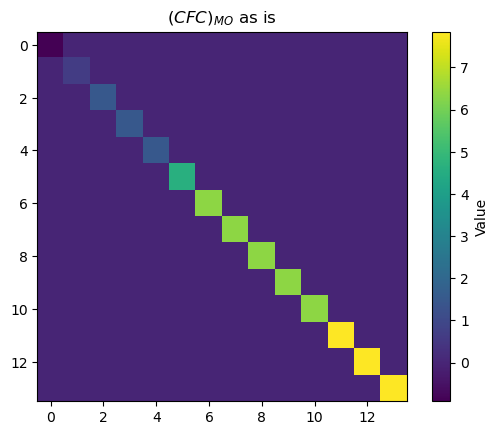

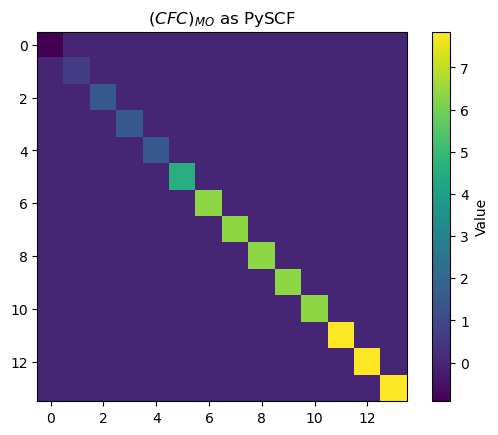

[-0.91762508  0.6366428   1.50051369  1.50051369  1.50051369  4.60856321
  6.35760442  6.35760442  6.35760442  6.35760442  6.35760442  7.84835915
  7.84835915  7.84835915]
[-0.91762508  0.6366428   1.50051369  1.50051369  1.50051369  4.60856321
  6.35760442  6.35760442  6.35760442  6.35760442  6.35760442  7.84835915
  7.84835915  7.84835915]


In [5]:
plot = plot_map(
    F_MO_ca,
    title="$(CFC)_{MO}$ as is",
)
plot = plot_map(
    F_MO_pyscf,
    title="$(CFC)_{MO}$ as PySCF",
)

print(np.diag(F_MO_ca))
print(np.diag(F_MO_pyscf))

And we can see that this arises from issues in diagonalization:

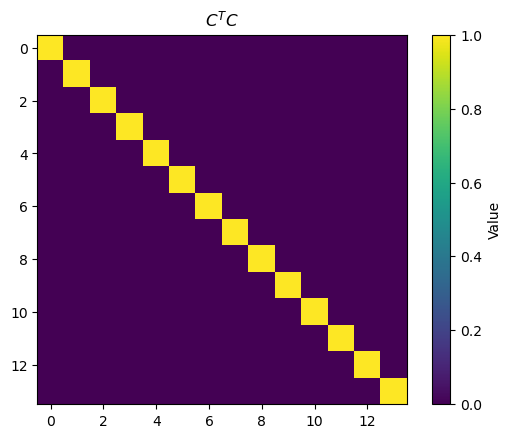

In [6]:
X = res.X
plot_map(
    res.C_prime.T.real @ res.C_prime.real,
    title="$C^TC$",
)

Where this should be the identity matrix, but however, it is not. Therefore, since we have the last $F_{MO}$ matrix, we can check what went wrong.

---

## The eigh solution
As we are failing even in the real case, lets first try to see what happens with the hermitian matrix solver. The data presented now was obtained from the incorrect version. For educational purposes, as this is (should) be now corrected, the only way to keep the legacy notebook is this.

Considering the $F_{MO}$ and the "diagonalization" product:

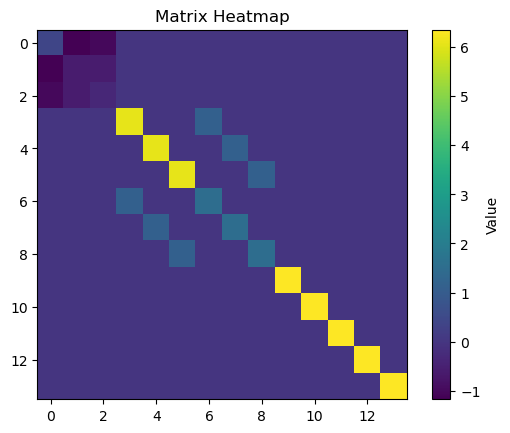

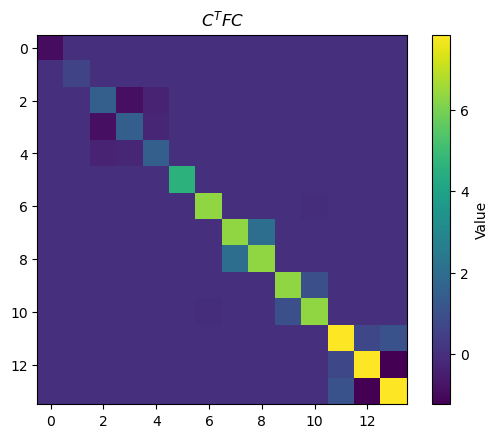

In [7]:
F_MO = np.loadtxt("data/F_MO_original.dat")
C_wr = np.loadtxt("data/C_MO_wrong.dat")
plot_map(F_MO.real)
plot_map((C_wr.T @ F_MO @ C_wr).real, title="$C^T F C$")

We can see that this is clearly wrong, as the supposedly diagonal matrix is not. Transforming $F_{MO}$ to the orthogonal representation of the AO basis:

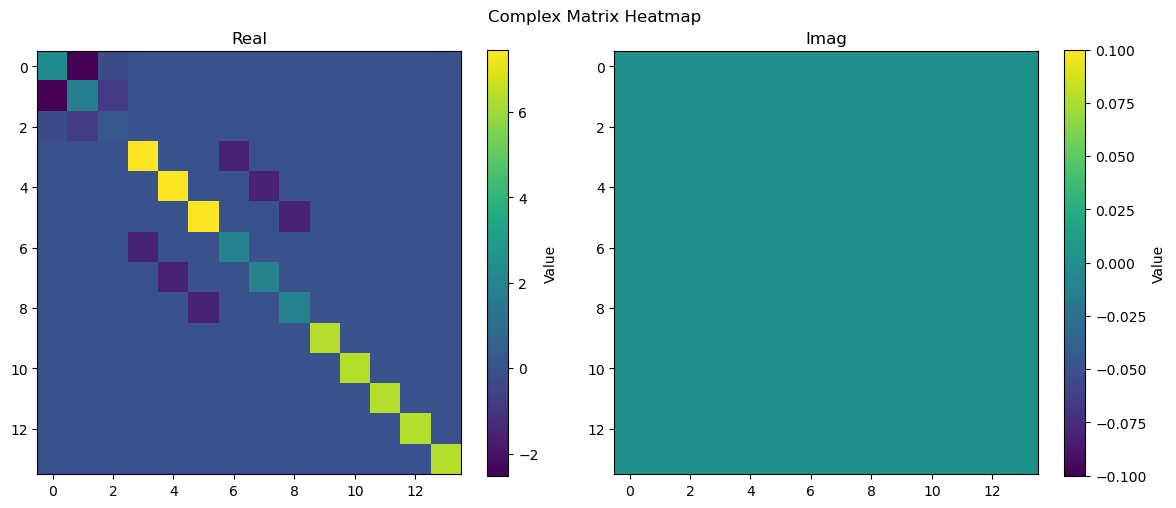

In [8]:
F_AO = X.T @ F_MO @ X
plot_map(F_AO)

And assuming real matrices lets diagonalize:

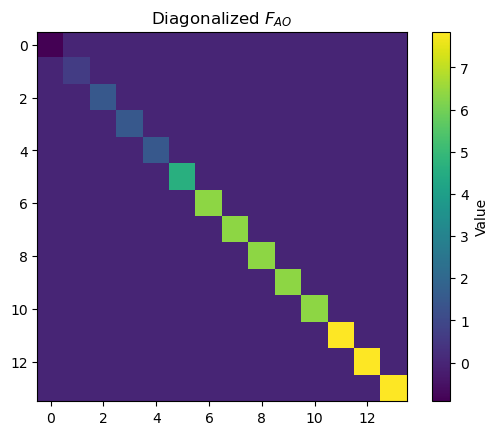

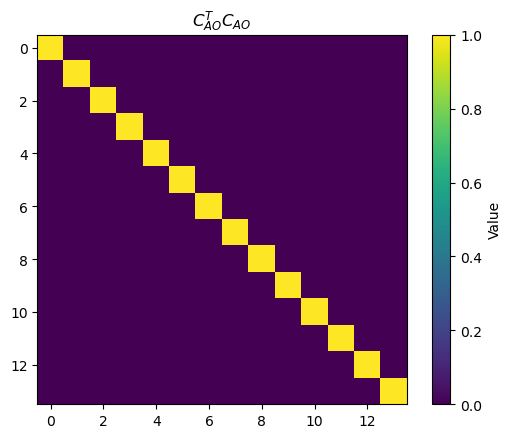

In [9]:
eval, evec = np.linalg.eigh(F_AO.real)

plot_map((evec.T @ F_AO @ evec).real, title="Diagonalized $F_{AO}$")
plot_map(evec.T @ evec, title="$C_{AO}^TC_{AO}$")

Which is what is expected, as the eigenvalues are block-diagonal and the eigenvectors are orthonormal. Transforming back to the MO basis:

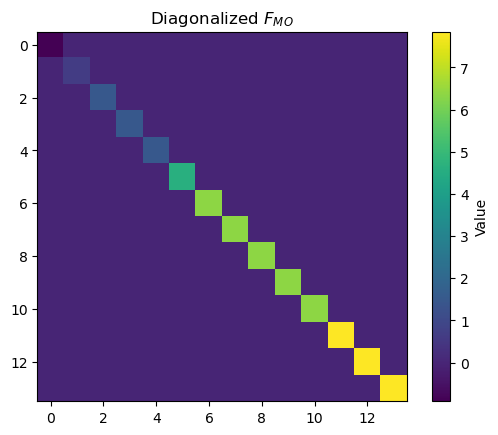

In [10]:
C_MO = X @ evec
plot_map((C_MO.T @ F_MO @ C_MO).real, title="Diagonalized $F_{MO}$")

Confirming that the transformation matrix is correct too. Lets try now with the generalized diagonalizing routine. 

----

## Wrong Generalized matrix diagonalizer
We can try now with the generalized diagonalizing routine that supposedly performs a Gram-Schmidt orthonormalization of the eigenvectors:

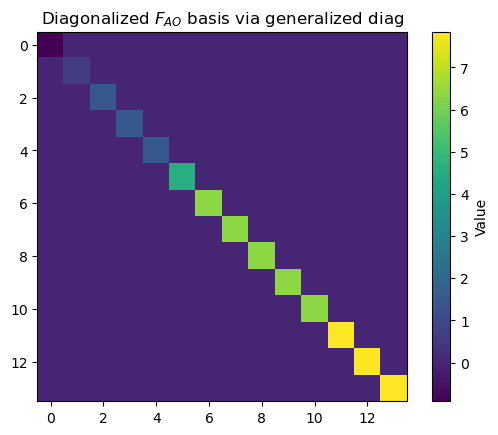

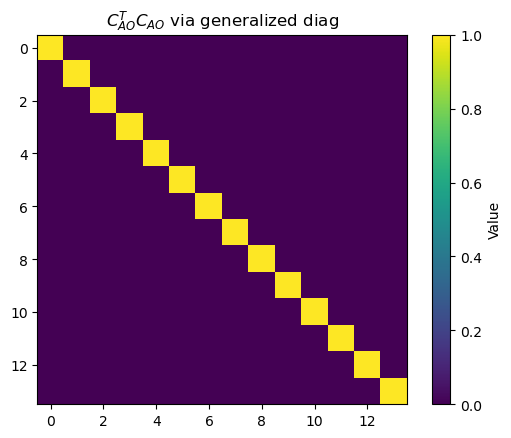

In [11]:
R_prime, _, e_values, C_prime = _diagonalize_gram(F_AO, "eigh")

plot_map(
    (C_prime.T @ F_AO @ C_prime).real,
    title="Diagonalized $F_{AO}$ basis via generalized diag",
)

plot_map((C_prime.T @ C_prime).real, title="$C_{AO}^TC_{AO}$ via generalized diag")

Which is indeed problematic as eigenvectors are not orthonotmalized as wanted. Lets get a step back and just use the diagonalizer without the extra GS we added:

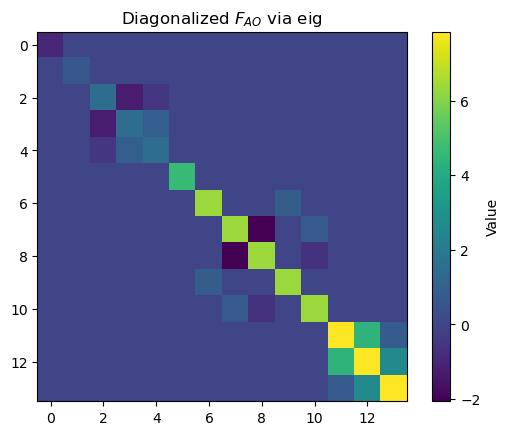

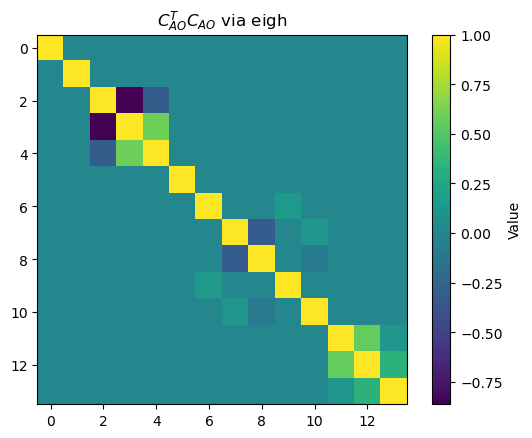

In [12]:
eval, evec = np.linalg.eig(F_AO)

idx = eval.argsort()
eval = eval[idx]
evec = evec[:, idx]

plot_map((evec.T.conj() @ F_AO @ evec).real, title="Diagonalized $F_{AO}$ via eig")
plot_map((evec.T.conj() @ evec).real, title="$C_{AO}^TC_{AO}$ via eigh")

Which is the same as before, so the issue is that the Gram-Schmidt orthogonalization is acomplishing nothing. Therefore there is something wrong with our GS function. 

---

## Manually orthonormalizing
To be sure that the GS works correctly, we will try to solve this example manually before trying to generalize. We start with the $p$ orbitals:

In [13]:
v = gram_schmidt(evec[:, 2:5])
copy = np.copy(evec)
copy[:, 2:5] = v

In [14]:
print("Column product after GS orthogonalization:")
print("Column 2 and 3 dot product:", (copy[:, 2].T @ copy[:, 3]).real)
print("Column 2 and 4 dot product:", (copy[:, 2].T @ copy[:, 4]).real)
print("Column 3 and 4 dot product:", (copy[:, 3].T @ copy[:, 4]).real)
print("Column 2 norm:", (copy[:, 2].T @ copy[:, 2]).real)
print("Column 3 norm:", (copy[:, 3].T @ copy[:, 3]).real)
print("Column 4 norm:", (copy[:, 4].T @ copy[:, 4]).real)

Column product after GS orthogonalization:
Column 2 and 3 dot product: 1.555831144341996e-16
Column 2 and 4 dot product: 4.301564818731202e-17
Column 3 and 4 dot product: 4.170593451830487e-17
Column 2 norm: 1.0000000000000002
Column 3 norm: 1.0
Column 4 norm: 1.0


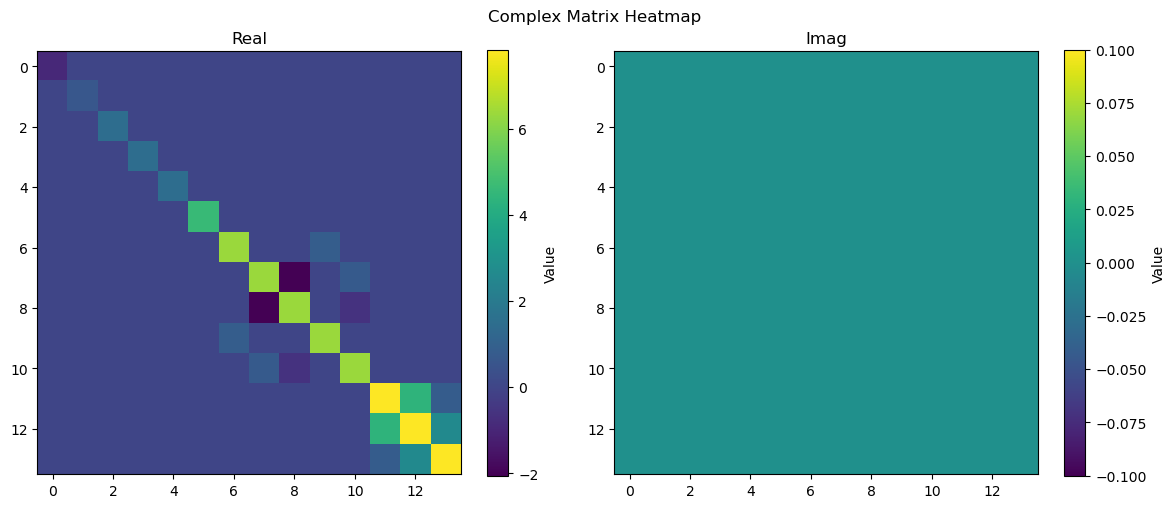

[-0.91762508+0.j  0.6366428 +0.j  1.50051369+0.j  1.50051369+0.j
  1.50051369+0.j  4.60856321+0.j  6.35760442+0.j  6.35760442+0.j
  6.35760442+0.j  6.35760442+0.j  6.35760442+0.j  7.84835915+0.j
  7.84835915+0.j  7.84835915+0.j]


In [15]:
plot_map(copy.T @ F_AO @ copy)

print(np.diag(copy.T @ F_AO @ copy))

And we can see that just using the GS scheme with the 2p orbitals, they are orthonormalized and the fock matrix is diagonal and conserves degeneracies. This proves that the issue was an error in the handler of degenerate spaces to input to the GS scheme. 

Now we do the same with the $d$ ones: 

In [16]:
dcols = evec[:, 6:11].real
w = gram_schmidt(evec[:, 6:11])

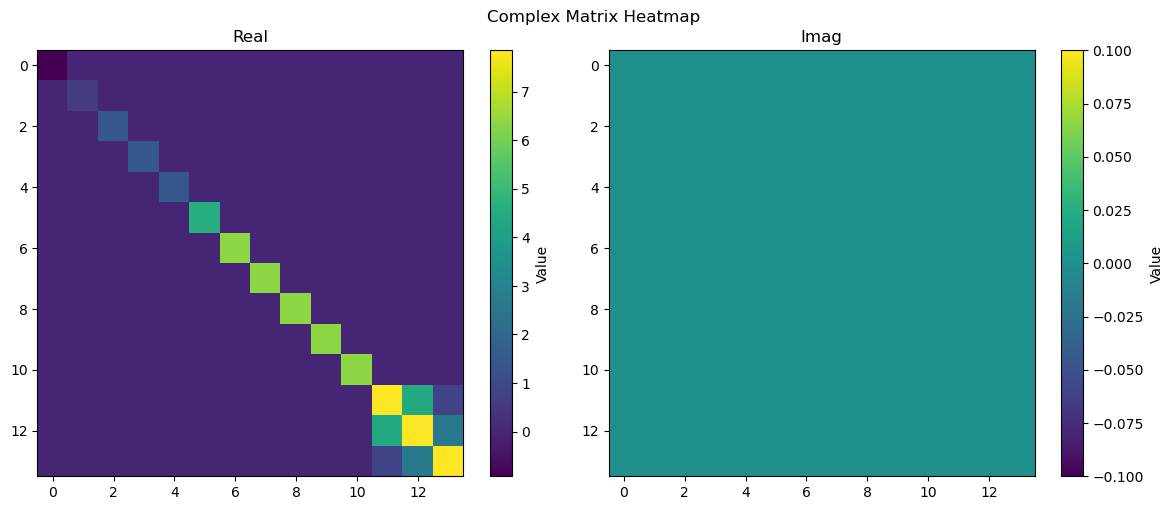

[-0.91762508+0.j  0.6366428 +0.j  1.50051369+0.j  1.50051369+0.j
  1.50051369+0.j  4.60856321+0.j  6.35760442+0.j  6.35760442+0.j
  6.35760442+0.j  6.35760442+0.j  6.35760442+0.j  7.84835915+0.j
  7.84835915+0.j  7.84835915+0.j]


In [17]:
copy[:, 6:11] = w
plot_map(copy.T @ F_AO @ copy)

print(np.diag(copy.T @ F_AO @ copy))

And the last $p$ orbitals

In [18]:
z = gram_schmidt(evec[:, -3:])

copy[:, -3:] = z

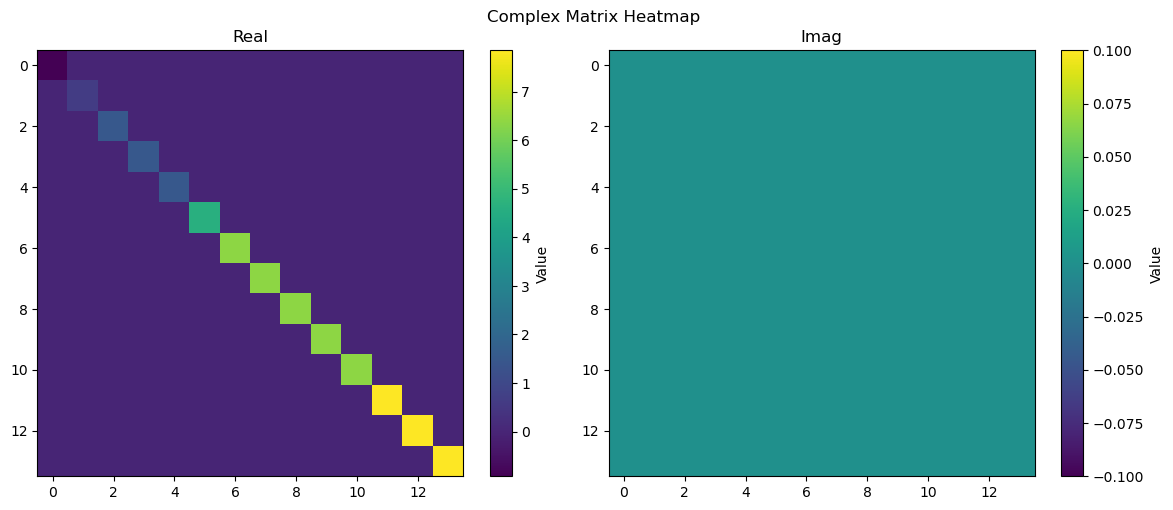

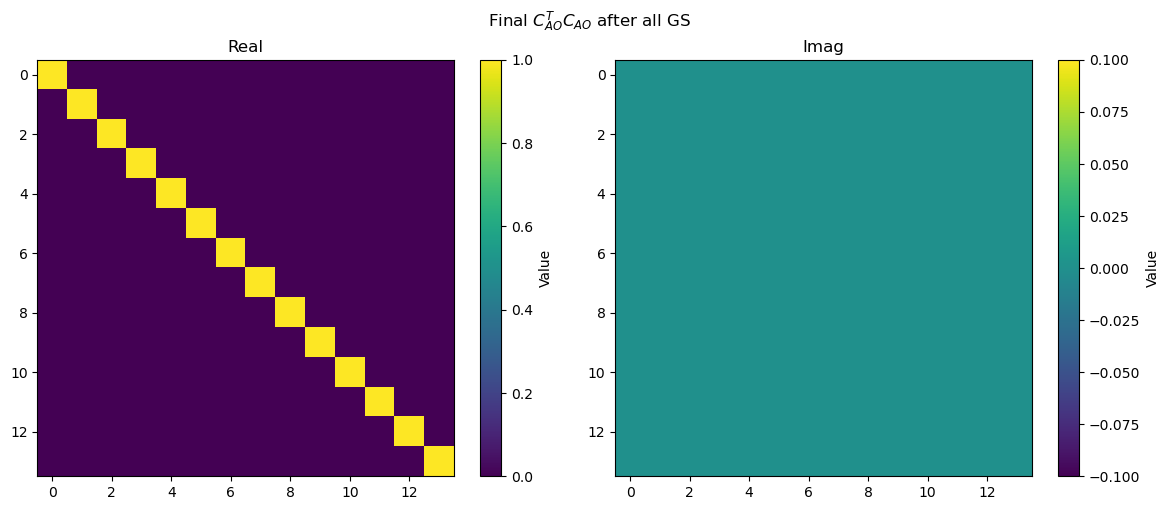

[-0.91762508+0.j  0.6366428 +0.j  1.50051369+0.j  1.50051369+0.j
  1.50051369+0.j  4.60856321+0.j  6.35760442+0.j  6.35760442+0.j
  6.35760442+0.j  6.35760442+0.j  6.35760442+0.j  7.84835915+0.j
  7.84835915+0.j  7.84835915+0.j]


In [19]:
plot_map(copy.T @ F_AO @ copy)
plot_map(copy.T @ copy, title="Final $C_{AO}^TC_{AO}$ after all GS")

print(np.diag(copy.T @ F_AO @ copy))

With a completely diagonal $F_{AO}$ matrix and with orthonormal $C_{AO}$. 

---

## Transformation to MO basis
Now we just have to check if the solutions obtained are fine in the MO representation:

In [20]:
C_MO = X @ copy

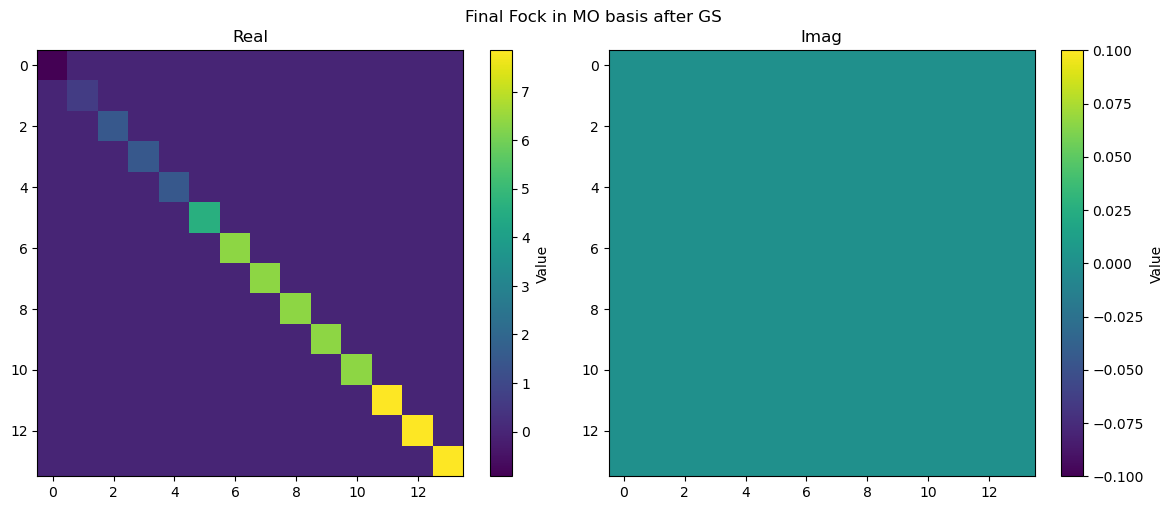

In [21]:
plot_map(C_MO.T @ F_MO @ C_MO, title="Final Fock in MO basis after GS")

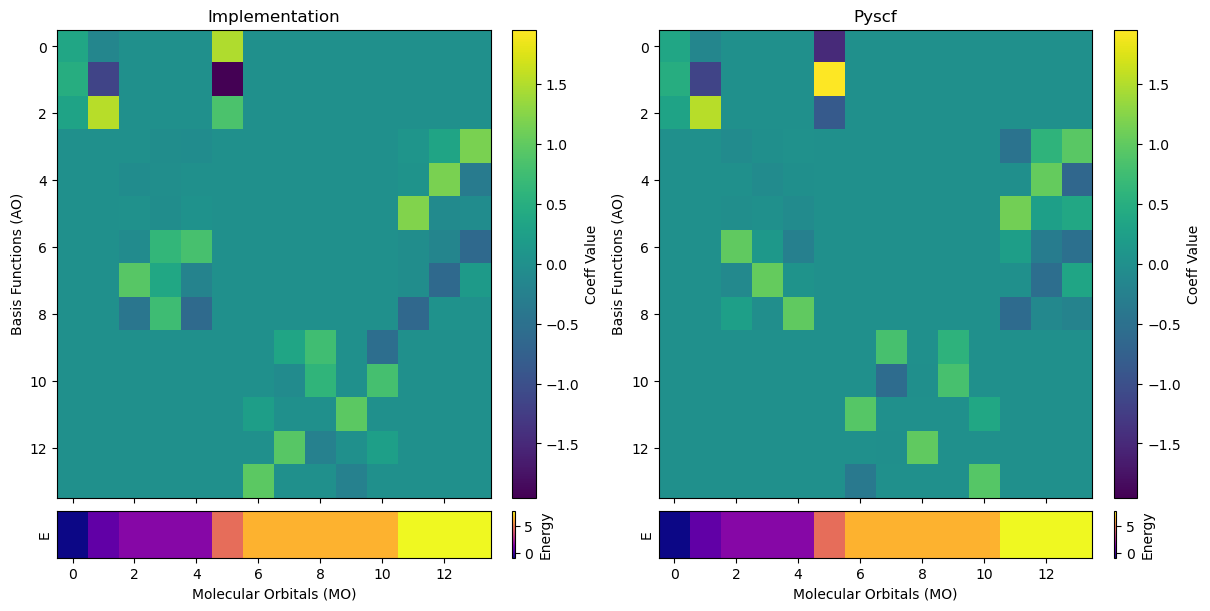

In [22]:
p = plot_mo_analysis(
    C_MO.real,
    np.diag(C_MO.T @ F_MO @ C_MO).real,
    mf.mo_coeff,
    mf.mo_energy,
    titles=["Implementation", "Pyscf"],
)

While still not exacly the same, at least the MO diagonal matrix energies are well defined. 

---

# Generalization
And this is the generalized function for the previously performed manipulations:

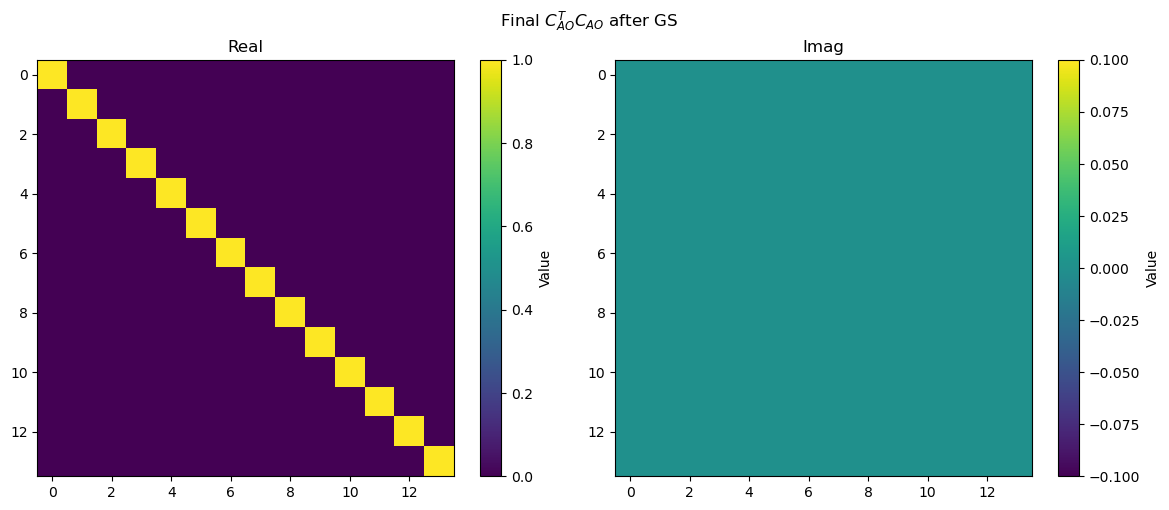

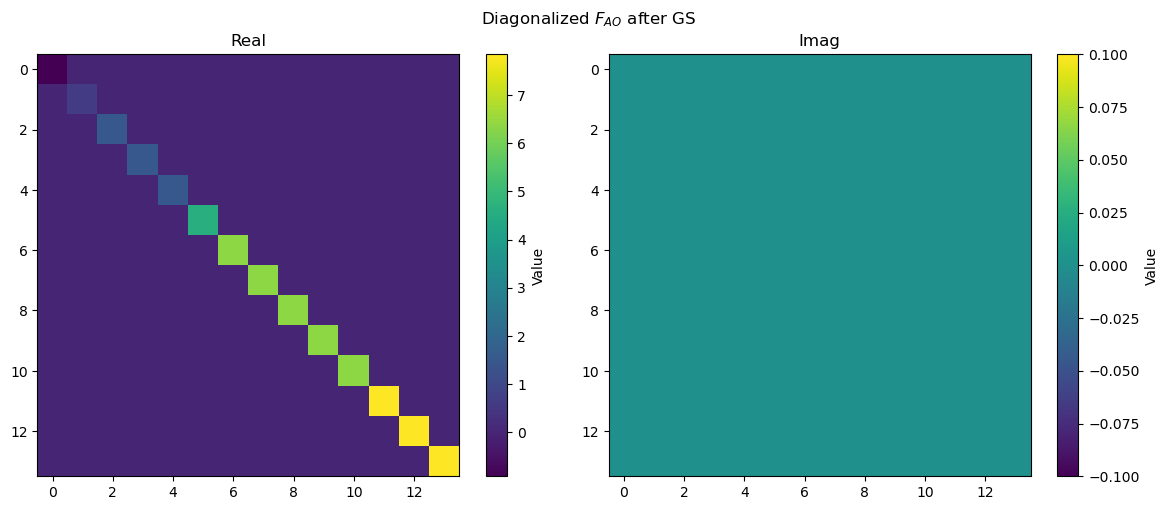

In [23]:
def orthonormalize2(eval, evec):
    ener, n_deg = count_degen2(eval)
    # print("Energy snd degeneracy in Fock eigenvalues:")

    # for e, d in zip(ener, n_deg):
    #     print(f"{e:.6f}   {d}")

    copyy = np.copy(evec)

    distinct_evals = len(n_deg)
    for i in range(distinct_evals):
        # print(f"Processing degenerate set {ener[i]} with degeneracy {n_deg[i]}")
        if n_deg[i] != 1:
            # print(n_deg[0:i-1])
            idx_str = sum(n_deg[0:i])
            # print('Starting on column ', idx_str)
            idx_end = idx_str + n_deg[i]
            # print(evec[:, idx_str:idx_end].real)
            v = gram_schmidt(evec[:, idx_str:idx_end])
            copyy[:, idx_str:idx_end] = v

        # else:
        #     print('Nothing to do\n')

    return copyy


copyy = orthonormalize2(eval, evec)
plot_map(copyy.T @ copyy, title="Final $C_{AO}^TC_{AO}$ after GS")
plot_map(copyy.T @ F_AO @ copyy, title="Diagonalized $F_{AO}$ after GS")

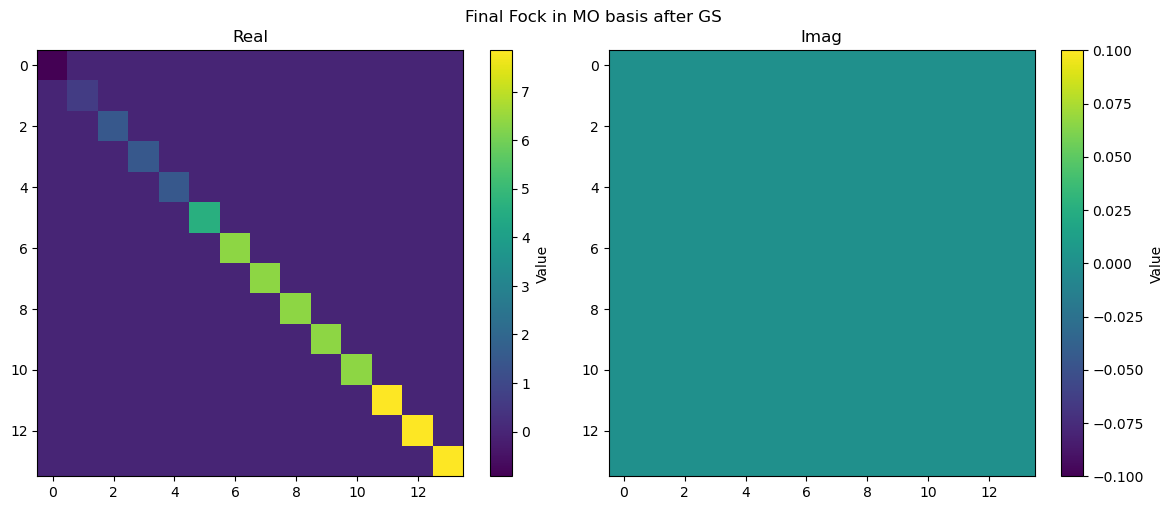

In [24]:
C_MO = X @ copyy
plot_map(C_MO.T @ F_MO @ C_MO, title="Final Fock in MO basis after GS")